In [1]:
import pandas as pd
import numpy as np


In [2]:
import scipy.stats as stats

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer

In [6]:
df= pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df=df[["Age","Fare","Survived"]]

In [8]:
df.head()

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [14]:
df.isnull().sum()

Age         177
Fare          0
Survived      0
dtype: int64

In [15]:
df["Age"].fillna(df["Age"].mean(),inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_35400\2595122914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


In [16]:
df.isnull().sum()

Age         0
Fare        0
Survived    0
dtype: int64

In [18]:
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,0:2],df.iloc[:,-1],test_size=0.2,random_state=45)

In [21]:
len(X_train)+len(X_test)==df.shape[0]

True

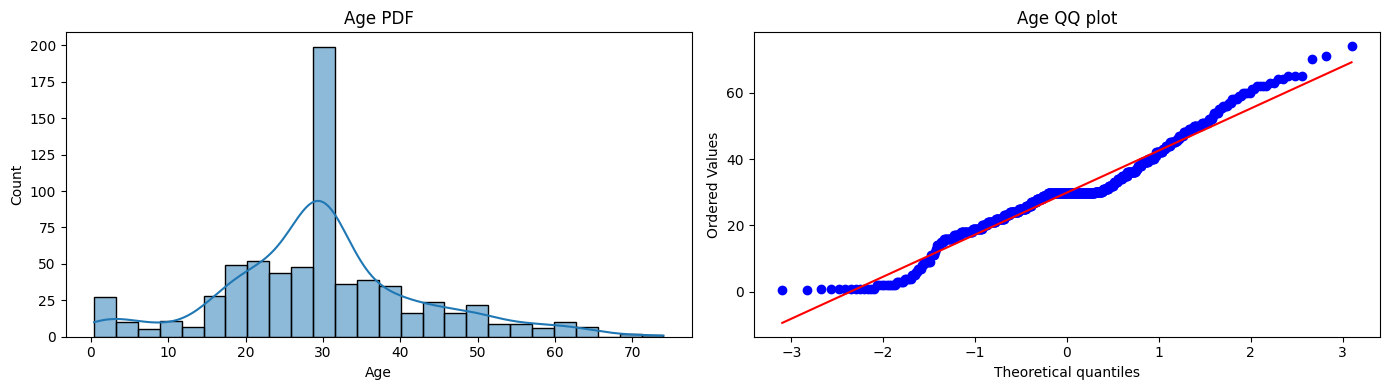

In [32]:
plt.figure(figsize=(14,4))
plt.subplot(121)
# sns.distplot(data=X_train,x="Age",kde=True)
sns.histplot(data=X_train, x="Age", kde=True)
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train["Age"],dist="norm",plot=plt)
plt.title("Age QQ plot")
plt.tight_layout()
plt.show()

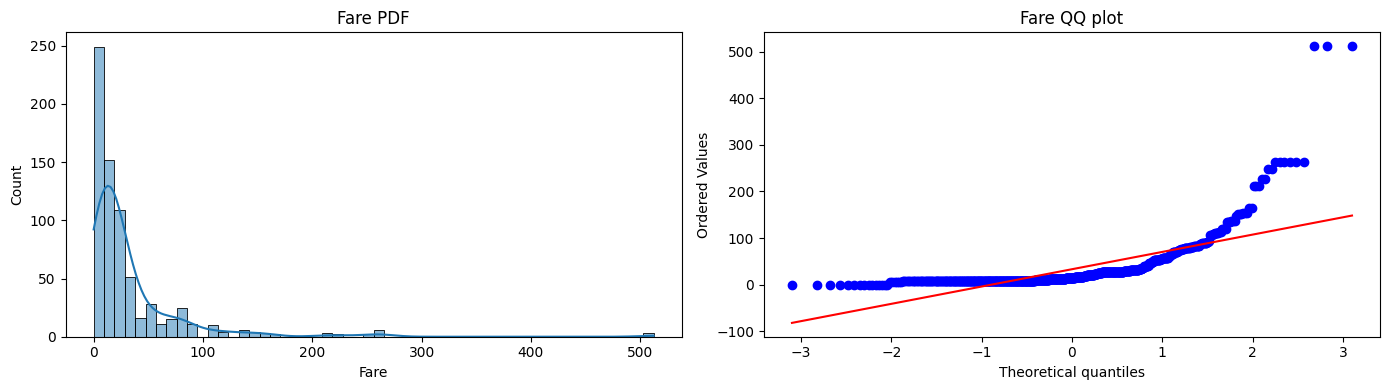

In [33]:
plt.figure(figsize=(14,4))
plt.subplot(121)

sns.histplot(data=X_train, x="Fare", kde=True)
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(X_train["Fare"],dist="norm",plot=plt)
plt.title("Fare QQ plot")
plt.tight_layout()
plt.show()

In [34]:
clf=LogisticRegression()
clf1=DecisionTreeClassifier()


In [35]:
clf.fit(X_train,y_train)
clf1.fit(X_train,y_train)

y_pred=clf.predict(X_test)
y_pred1=clf1.predict(X_test)

print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred1))

0.6759776536312849
0.6312849162011173


In [37]:
trf=FunctionTransformer(func=np.log1p)

In [41]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

In [42]:
clf=LogisticRegression()
clf1=DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf1.fit(X_train_transformed,y_train)

y_pred=clf.predict(X_test_transformed)
y_pred1=clf1.predict(X_test_transformed)

print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred1))

0.6927374301675978
0.6480446927374302
